# Feature Selection Lab

This notebook demonstrates how feature selection can simplify a classification problem while preserving strong model performance.

In this version of the lab:

- I have changed the dataset to the **Wine Recognition** dataset,
- and the baseline model has been changed to **Logistic Regression**,


## What you will do

You will:

1. load and inspect the dataset,
2. build a baseline classifier,
3. apply multiple feature selection methods,
4. compare the selected feature sets, and
5. decide which subset is the most practical choice.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC

print("Libraries imported successfully.")
print(f"scikit-learn version: {sklearn_version}")
print("This lab uses Logistic Regression as the evaluation model.")


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.
scikit-learn version: 1.8.0
This lab uses Logistic Regression as the evaluation model.


## Load the dataset

The notebook uses a local CSV file stored in the `data` folder.


In [2]:

df = pd.read_csv("./data/wine_data.csv")

print(f"Dataset shape: {df.shape}")
print("Class labels:", sorted(df["target_name"].unique()))
display(df.head())


Dataset shape: (178, 15)
Class labels: ['class_0', 'class_1', 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## Inspect the dataset

Check the data types, missing values, and the target distribution before building a model.


In [3]:

summary_df = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum()
})

print("Column summary:")
display(summary_df)

print("\nTarget distribution:")
display(df["target_name"].value_counts().rename_axis("class").reset_index(name="count"))


Column summary:


,data_type,missing_values
alcohol,float64,0
malic_acid,float64,0
ash,float64,0
alcalinity_of_ash,float64,0
magnesium,float64,0
total_phenols,float64,0
flavanoids,float64,0
nonflavanoid_phenols,float64,0
proanthocyanins,float64,0
color_intensity,float64,0



Target distribution:


,class,count
0,class_1,71
1,class_0,59
2,class_2,48


## Prepare features and target

We will keep `target` as the numeric label for training and exclude `target_name` from the feature matrix.


In [4]:

X = df.drop(columns=["target", "target_name"])
y = df["target"]

print(f"Number of input features: {X.shape[1]}")
print("Feature names:")
display(pd.DataFrame({"feature": X.columns}))


Number of input features: 13
Feature names:


,feature
0,alcohol
1,malic_acid
2,ash
3,alcalinity_of_ash
4,magnesium
5,total_phenols
6,flavanoids
7,nonflavanoid_phenols
8,proanthocyanins
9,color_intensity


## Define helper functions

These functions standardize the data, train the Logistic Regression model, and return evaluation metrics.


In [5]:

def evaluate_logistic_regression(X_data, y_data, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, stratify=y_data, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=5000, solver="lbfgs")
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    metrics = pd.DataFrame({
        "Accuracy": [accuracy_score(y_test, predictions)],
        "Precision": [precision_score(y_test, predictions, average="weighted", zero_division=0)],
        "Recall": [recall_score(y_test, predictions, average="weighted", zero_division=0)],
        "F1 Score": [f1_score(y_test, predictions, average="weighted", zero_division=0)],
        "Feature Count": [X_data.shape[1]]
    })

    cm = confusion_matrix(y_test, predictions)
    return metrics, cm

print("Helper functions are ready.")
print("Next, we will compute the baseline performance with all features.")


Helper functions are ready.
Next, we will compute the baseline performance with all features.


## Baseline model with all features

In [6]:

baseline_metrics, baseline_cm = evaluate_logistic_regression(X, y)
baseline_metrics.index = ["All features"]

print("Baseline evaluation:")
display(baseline_metrics)

print("Confusion matrix:")
display(pd.DataFrame(baseline_cm))


Baseline evaluation:


,Accuracy,Precision,Recall,F1 Score,Feature Count
All features,0.972222,0.974074,0.972222,0.97197,13


Confusion matrix:


,0,1,2
0,12,0,0
1,0,14,0
2,0,1,9


## Correlation matrix

A correlation heatmap helps identify features that are strongly related to the target or to one another.


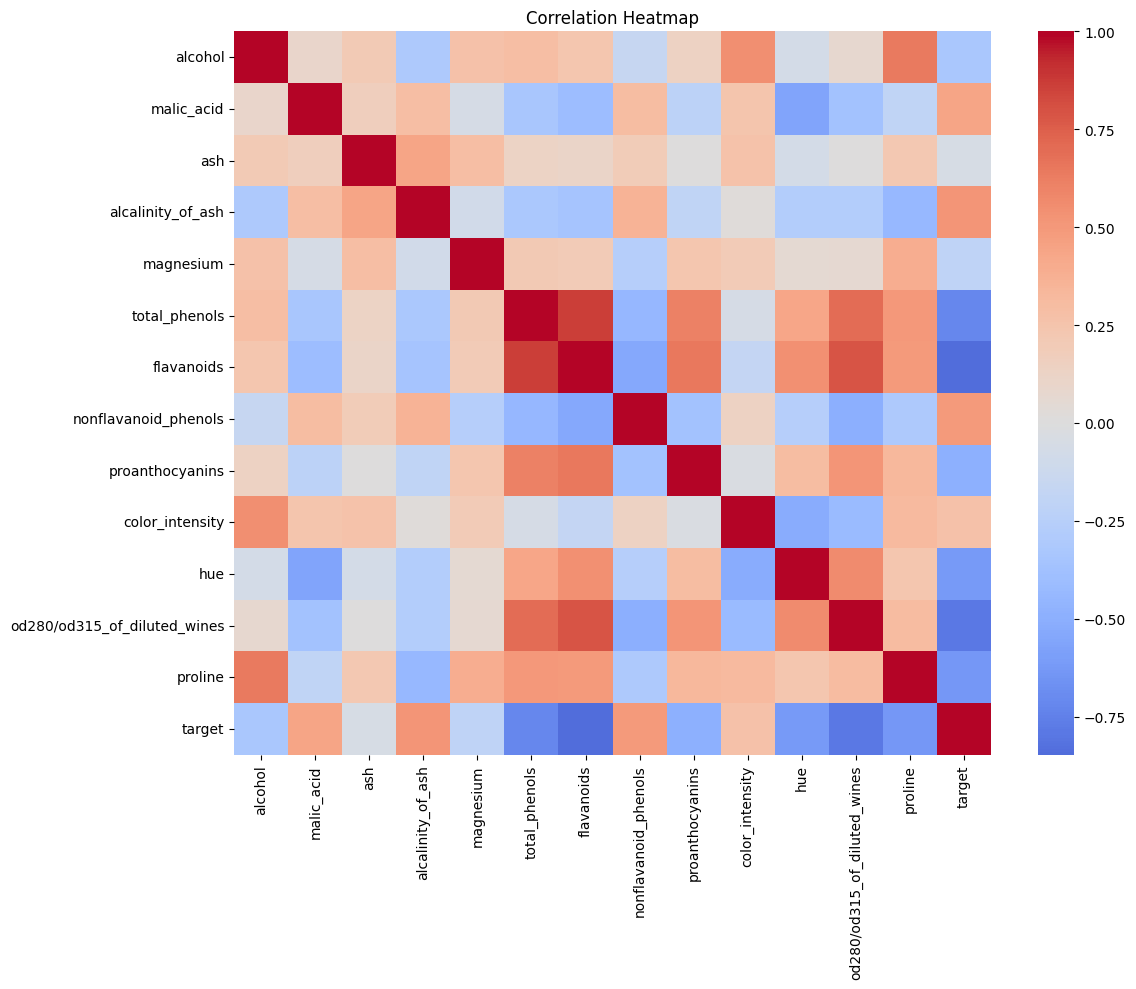

Heatmap displayed successfully.


In [7]:

plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(columns=["target_name"]).corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Heatmap displayed successfully.")


## Correlation-based feature filtering

We first select features whose absolute correlation with the target is greater than a threshold.


In [8]:

target_correlations = correlation_matrix["target"].drop("target").abs().sort_values(ascending=False)
correlation_threshold = 0.15
corr_selected_features = target_correlations[target_correlations > correlation_threshold].index.tolist()

print(f"Correlation threshold: {correlation_threshold}")
print(f"Selected {len(corr_selected_features)} features:")
display(pd.DataFrame({"feature": corr_selected_features, "abs_target_corr": target_correlations[corr_selected_features].values}))


Correlation threshold: 0.15
Selected 12 features:


,feature,abs_target_corr
0,flavanoids,0.847498
1,od280/od315_of_diluted_wines,0.788230
2,total_phenols,0.719163
3,proline,0.633717
4,hue,0.617369
5,alcalinity_of_ash,0.517859
6,proanthocyanins,0.499130
7,nonflavanoid_phenols,0.489109
8,malic_acid,0.437776
9,alcohol,0.328222


In [9]:

corr_metrics, corr_cm = evaluate_logistic_regression(df[corr_selected_features], y)
corr_metrics.index = ["Correlation filter"]

print("Evaluation after correlation-based filtering:")
display(corr_metrics)


Evaluation after correlation-based filtering:


,Accuracy,Precision,Recall,F1 Score,Feature Count
Correlation filter,0.972222,0.974074,0.972222,0.97197,12


## Univariate selection with ANOVA F-test

This method ranks features individually and keeps the top scoring ones.


In [10]:

kbest_selector = SelectKBest(score_func=f_classif, k=8)
kbest_selector.fit(X, y)

kbest_features = X.columns[kbest_selector.get_support()].tolist()
kbest_scores = pd.DataFrame({
    "feature": X.columns,
    "f_score": kbest_selector.scores_
}).sort_values("f_score", ascending=False)

print("Top ANOVA F-test features:")
display(kbest_scores.head(8).reset_index(drop=True))
print("Selected features:")
display(pd.DataFrame({"feature": kbest_features}))


Top ANOVA F-test features:


,feature,f_score
0,flavanoids,233.925873
1,proline,207.920374
2,od280/od315_of_diluted_wines,189.972321
3,alcohol,135.077624
4,color_intensity,120.664018
5,hue,101.316795
6,total_phenols,93.733010
7,malic_acid,36.943425


Selected features:


,feature
0,alcohol
1,malic_acid
2,total_phenols
3,flavanoids
4,color_intensity
5,hue
6,od280/od315_of_diluted_wines
7,proline


In [11]:

kbest_metrics, kbest_cm = evaluate_logistic_regression(df[kbest_features], y)
kbest_metrics.index = ["ANOVA F-test"]

print("Evaluation after ANOVA F-test selection:")
display(kbest_metrics)


Evaluation after ANOVA F-test selection:


,Accuracy,Precision,Recall,F1 Score,Feature Count
ANOVA F-test,0.972222,0.974074,0.972222,0.97197,8


## Wrapper method with Recursive Feature Elimination

RFE repeatedly removes less useful features until the requested number of features remains.


In [12]:

scaler_for_rfe = StandardScaler()
X_scaled_for_rfe = scaler_for_rfe.fit_transform(X)

rfe_selector = RFE(
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs"),
    n_features_to_select=8
)
rfe_selector.fit(X_scaled_for_rfe, y)

rfe_features = X.columns[rfe_selector.support_].tolist()

print("RFE selected features:")
display(pd.DataFrame({"feature": rfe_features}))


RFE selected features:


,feature
0,alcohol
1,ash
2,alcalinity_of_ash
3,flavanoids
4,color_intensity
5,hue
6,od280/od315_of_diluted_wines
7,proline


In [13]:

rfe_metrics, rfe_cm = evaluate_logistic_regression(df[rfe_features], y)
rfe_metrics.index = ["RFE"]

print("Evaluation after RFE:")
display(rfe_metrics)


Evaluation after RFE:


,Accuracy,Precision,Recall,F1 Score,Feature Count
RFE,1.0,1.0,1.0,1.0,8


## Embedded method with tree-based importance

A tree ensemble can assign importance scores to features directly.


In [14]:

tree_model = ExtraTreesClassifier(n_estimators=300, random_state=42)
tree_model.fit(X, y)

tree_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

tree_selector = SelectFromModel(tree_model, threshold="median", prefit=True)
tree_features = X.columns[tree_selector.get_support()].tolist()

print("Top tree-based feature importances:")
display(tree_importances.head(10).reset_index(drop=True))
print("Selected features:")
display(pd.DataFrame({"feature": tree_features}))


Top tree-based feature importances:


,feature,importance
0,flavanoids,0.147968
1,proline,0.138961
2,alcohol,0.124933
3,od280/od315_of_diluted_wines,0.114787
4,color_intensity,0.114155
5,hue,0.086320
6,total_phenols,0.067473
7,malic_acid,0.043216
8,magnesium,0.041790
9,alcalinity_of_ash,0.035538


Selected features:


,feature
0,alcohol
1,total_phenols
2,flavanoids
3,color_intensity
4,hue
5,od280/od315_of_diluted_wines
6,proline


In [15]:

tree_metrics, tree_cm = evaluate_logistic_regression(df[tree_features], y)
tree_metrics.index = ["Tree importance"]

print("Evaluation after tree-based selection:")
display(tree_metrics)


Evaluation after tree-based selection:


,Accuracy,Precision,Recall,F1 Score,Feature Count
Tree importance,1.0,1.0,1.0,1.0,7


## Embedded method with L1 regularization

L1 regularization encourages sparse solutions and can eliminate weaker features.


In [16]:

scaler_for_l1 = StandardScaler()
X_scaled_for_l1 = scaler_for_l1.fit_transform(X)

l1_selector_model = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
l1_selector_model.fit(X_scaled_for_l1, y)

l1_selector = SelectFromModel(l1_selector_model, prefit=True)
l1_features = X.columns[l1_selector.get_support()].tolist()

l1_coefficients = np.abs(l1_selector_model.coef_).max(axis=0)
l1_summary = pd.DataFrame({
    "feature": X.columns,
    "max_abs_weight": l1_coefficients,
    "selected": X.columns.isin(l1_features)
}).sort_values("max_abs_weight", ascending=False)

print("L1-based feature summary:")
display(l1_summary.reset_index(drop=True))
print("Selected features:")
display(pd.DataFrame({"feature": l1_features}))


L1-based feature summary:


,feature,max_abs_weight,selected
0,proline,0.575022,True
1,flavanoids,0.521474,True
2,color_intensity,0.446722,True
3,alcohol,0.418887,True
4,hue,0.291184,True
5,alcalinity_of_ash,0.255053,True
6,od280/od315_of_diluted_wines,0.243443,True
7,ash,0.229298,True
8,malic_acid,0.114300,True
9,proanthocyanins,0.030987,True


Selected features:


,feature
0,alcohol
1,malic_acid
2,ash
3,alcalinity_of_ash
4,flavanoids
5,proanthocyanins
6,color_intensity
7,hue
8,od280/od315_of_diluted_wines
9,proline


In [17]:

l1_metrics, l1_cm = evaluate_logistic_regression(df[l1_features], y)
l1_metrics.index = ["L1 selection"]

print("Evaluation after L1-based selection:")
display(l1_metrics)


Evaluation after L1-based selection:


,Accuracy,Precision,Recall,F1 Score,Feature Count
L1 selection,0.972222,0.974074,0.972222,0.97197,10


## Compare all methods

In [18]:

results = pd.concat([
    baseline_metrics,
    corr_metrics,
    kbest_metrics,
    rfe_metrics,
    tree_metrics,
    l1_metrics
])

results = results.sort_values(by=["F1 Score", "Accuracy"], ascending=False)

print("Final comparison table:")
display(results)


Final comparison table:


,Accuracy,Precision,Recall,F1 Score,Feature Count
RFE,1.000000,1.000000,1.000000,1.00000,8
Tree importance,1.000000,1.000000,1.000000,1.00000,7
All features,0.972222,0.974074,0.972222,0.97197,13
Correlation filter,0.972222,0.974074,0.972222,0.97197,12
ANOVA F-test,0.972222,0.974074,0.972222,0.97197,8
L1 selection,0.972222,0.974074,0.972222,0.97197,10


## Final observations

This lab shows that feature selection can reduce the number of inputs while keeping performance very strong. In this notebook, several reduced feature sets matched or improved on the baseline model, which makes them good candidates when you want simpler models and faster training.


In [19]:

best_method = results.index[0]
best_feature_count = int(results.iloc[0]["Feature Count"])
best_f1 = float(results.iloc[0]["F1 Score"])

print(f"Best-performing method in this run: {best_method}")
print(f"Feature count used: {best_feature_count}")
print(f"Weighted F1 score: {best_f1:.4f}")
print("Notebook completed successfully.")


Best-performing method in this run: RFE
Feature count used: 8
Weighted F1 score: 1.0000
Notebook completed successfully.
